## Squidpy Analyse

Creator: Mohammad Vali Sanian (mohammad.sanian@helsinki.fi) (mv10@sanger.ac.uk).

Date of Creation: 18.08.2024

Date of Last Modification: 19.08.2024

# 1. Setup

## 1.1 Libraries 

In [5]:
import anndata as ad
import scanpy as sc
import squidpy as sq
import pandas as pd

# 2 DEG 

In [2]:
import anndata as ad
adata = ad.read_h5ad('/lustre/scratch126/cellgen/team361/mv10/nichejepa-reproducibility/nichejepa-reproducibility/datasets/st_data/silver/sim1_1105fts_10000locs/sim1_1105fts_10000locs.h5ad')
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.tl.pca(adata)
sc.tl.rank_genes_groups(adata, 'cell_types', method='wilcoxon')

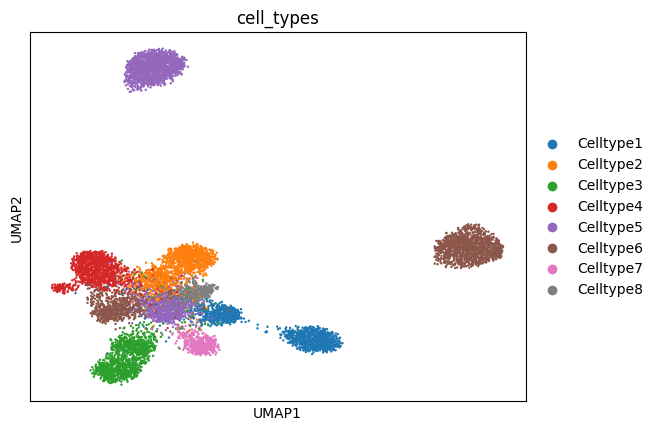

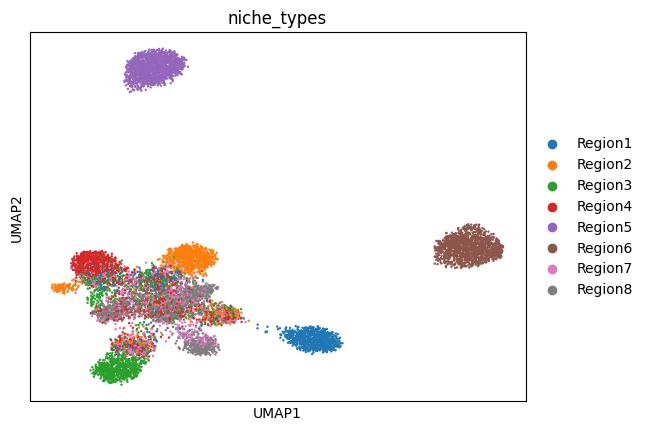

In [3]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cell_types"])
sc.pl.umap(adata, color=["niche_types"])

In [6]:
# Extract the results into a pandas DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
deg_df = pd.DataFrame({
    group: result['names'][group] for group in groups
}).head(10)  # Display top 10 differentially expressed genes per group

print(deg_df)

  Celltype1 Celltype2 Celltype3  Celltype4 Celltype5      Celltype6 Celltype7  \
0       Tnf      Gad1     Smim1  Atp6v1fnb      Nt5e      Tmprss11b   Rdh16f1   
1     Smim1    Map2k4      Ccr8       Gad1    Lrrc23         Ccdc65     Srp14   
2    Guca2a     Zfp36    Mrpl50       Odc1  Glipr1l3         Tcf7l2     Abcf3   
3    Gm3424    Lilra5   Rdh16f1        Csl   Or10p21       Pramel3d    Map2k4   
4      Egr1    Col1a2       Eda     Grin3a    Or2t26         Or5p60      Asb8   
5      Cdk1      Ier3   Gm45713  Ccl19-ps1     Ddhd1         Or5t17      Otoa   
6      Cav1     Dusp6    Bnip3l     Defa24     Or9a4        Ppp2r5d      Il11   
7     Insl5    Gm4131    Defa27      Trem2  Vmn1r202         Smndc1   Slc37a2   
8    Ifi205      Cdk6    Rhox4e      Ifna2   mt-Cytb  2810004N23Rik      Ccr8   
9      Btg2     Phpt1     Ifna2       Otoa    Or5au1         Defb38   Arhgef6   

  Celltype8  
0   Gm45713  
1    Gm4131  
2     Patz1  
3  Igkv5-39  
4    Defa27  
5     Srp14  
6   Tmem23

In [7]:
sc.tl.rank_genes_groups(adata, 'niche_types', method='wilcoxon')

In [8]:
# Extract the results into a pandas DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
deg_df = pd.DataFrame({
    group: result['names'][group] for group in groups
}).head(10)  # Display top 10 differentially expressed genes per group

print(deg_df)

   Region1   Region2     Region3    Region4   Region5        Region6  Region7  \
0     Egr1     Zfp36       Smim1  Atp6v1fnb  Vmn1r202         Ccdc65  Rdh16f1   
1     Cav1    Lilra5     Ccdc162     Grin3a     Ddhd1       Pramel3d    Abcf3   
2     Ska2    Col1a2      Or2w25      Trem2   Vmn2r27        Ppp2r5d  Gm11009   
3    Trib1      Ier3        Ccr8     Defa24   mt-Cytb         Defb38  Gm45713   
4     Cdk1      Gad1      Prss40  Ccl19-ps1    Gm3415         Or5p60   Tm7sf2   
5   Ifi205    Mrpl46  Ccdc121rt2       Odc1    Gm3629         Or5t17     Otoa   
6    Insl5  Vmn1r198      Mrpl50    Klk1b27  Glipr1l3          Nupl2    Agfg2   
7     Btg2   Bcl2a1c     Tnfsf12       Gad1     Acap2  2810004N23Rik     Asb8   
8  Gm28729      Lyg2        Egr2        Csl    Or2t26          Or1i2     Rara   
9    Smim1      Dkk1      H2-Eb1       Asb8    Or5au1         Zfp455    H2bu2   

   Region8  
0    Srp14  
1  Rdh16f1  
2    Patz1  
3     Ccr5  
4     Ccr7  
5      Npb  
6   Klk1b5  
7   

/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


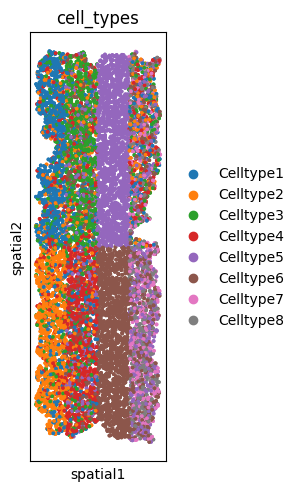

In [9]:
# Visualize cell types in tissue
sq.pl.spatial_scatter(adata, color="cell_types", shape=None) 

/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:946: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


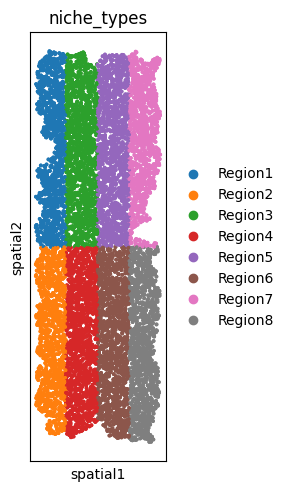

In [10]:
# Visualize cell types in tissue
sq.pl.spatial_scatter(adata, color="niche_types", shape=None) 

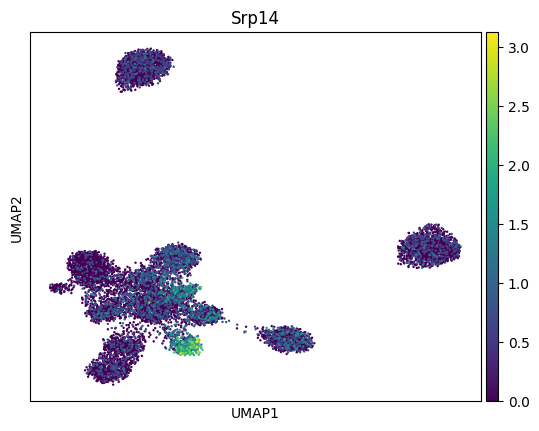

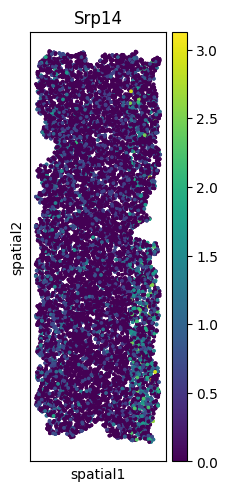

In [11]:
# Visualize incremented genes in UMAP PCA-reduced gene expression space
sc.pl.umap(adata, color=["Srp14"]) # region 6 cell type 6 prior source gene
# Visualize cell types in tissue
sq.pl.spatial_scatter(adata, color="Srp14", shape=None) 